# DINO의 교차엔트로피와 붕괴(collapse) — 손으로 만져보기

[main_dino.py의 `DINOLoss`](../main_dino.py#L363)가 하는 일을 **숫자와 그림으로** 이해하는 노트북이다.
수식은 최소한으로, 대신 직접 값을 찍어 보고 토이 모델을 학습시켜 붕괴가 실제로 일어나는 걸 본다.

읽는 순서:

1. **엔트로피** — 분포가 "뾰족한지 / 퍼졌는지"를 숫자 하나로
2. **교차엔트로피** — 두 분포가 다른 정도. 그리고 `H(q,p) = h(q) + KL(q‖p)` 분해
3. **`DINOLoss` 미니 재현** — 원본 코드와 1:1 대응
4. **자명해(붕괴) 시연** — 입력을 안 봐도 loss가 0이 되는 치트
5. **토이 학습 실험** — centering / sharpening 조합 4가지로 실제 붕괴 관찰
6. **요약 + 실전 함정**

의존성: `torch`, `matplotlib`만 쓴다. GPU 불필요, 전체 실행 1~2분.

In [1]:
import math, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
torch.set_printoptions(precision=3, sci_mode=False)

## 1. 엔트로피 — 분포의 "퍼진 정도"

확률분포 $p = (p_1, \dots, p_K)$의 엔트로피:

$$h(p) = -\sum_i p_i \log p_i$$

- 한 칸에 확률이 몰려 있으면(원-핫) → $h = 0$
- $K$칸에 골고루 퍼져 있으면(균등) → $h = \log K$ (최댓값)

DINO에서 $K$는 `--out_dim` = 65536이다. 여기서는 눈으로 볼 수 있게 $K=8$로 줄인다.

In [2]:
def entropy(p):
    return -(p * p.clamp_min(1e-12).log()).sum(-1)

K = 8
one_hot = F.one_hot(torch.tensor(3), K).float()
uniform = torch.full((K,), 1 / K)
peaked  = F.softmax(torch.tensor([4., 1., 0., 0., 0., 0., 0., 0.]), -1)

for name, p in [("one_hot", one_hot), ("peaked", peaked), ("uniform", uniform)]:
    print(f"{name:8s} p={p.numpy().round(3)}  h={entropy(p):.3f}")
print(f"\nlog K = {math.log(K):.3f}  ← 균등분포의 엔트로피 = 최댓값")

one_hot  p=[0. 0. 0. 1. 0. 0. 0. 0.]  h=-0.000
peaked   p=[0.862 0.043 0.016 0.016 0.016 0.016 0.016 0.016]  h=0.656
uniform  p=[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]  h=2.079

log K = 2.079  ← 균등분포의 엔트로피 = 최댓값


### 온도(temperature)가 엔트로피를 조절한다

softmax 전에 로짓을 온도 $\tau$로 나누면:

$$p_i = \frac{\exp(z_i/\tau)}{\sum_j \exp(z_j/\tau)}$$

- $\tau$ 작을수록 → 큰 로짓이 더 두드러짐 → **뾰족(sharp)** → 엔트로피 ↓
- $\tau$ 클수록 → 차이가 뭉개짐 → **평평** → 엔트로피 ↑

DINO의 **sharpening**은 정확히 이것이다: teacher에 낮은 온도(0.04)를 걸어 분포를 뾰족하게 만든다.

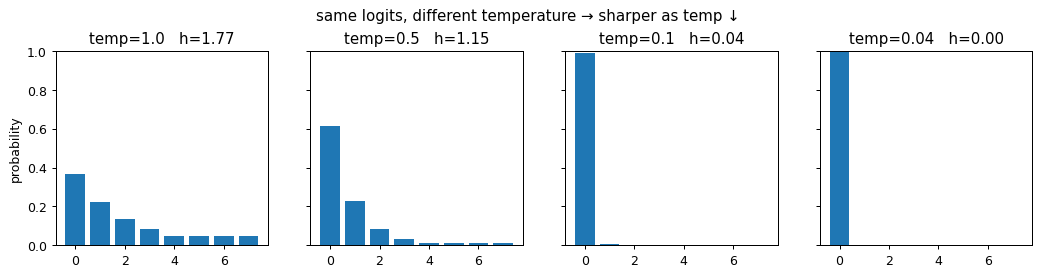

In [3]:
logits = torch.tensor([2.0, 1.5, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])
temps = [1.0, 0.5, 0.1, 0.04]

fig, axes = plt.subplots(1, len(temps), figsize=(14, 2.8), sharey=True)
for ax, t in zip(axes, temps):
    p = F.softmax(logits / t, -1)
    ax.bar(range(K), p.numpy())
    ax.set_title(f"temp={t}   h={entropy(p):.2f}")
    ax.set_ylim(0, 1)
axes[0].set_ylabel("probability")
plt.suptitle("same logits, different temperature → sharper as temp ↓", y=1.05)
plt.show()

## 2. 교차엔트로피 — "q를 정답으로 놓고 p를 채점"

$$H(q, p) = -\sum_i q_i \log p_i$$

- $q$: 정답 취급하는 분포 (target)
- $p$: 모델의 예측

지도학습에서 $q$는 원-핫 레이블이라 $-\log p_{\text{정답}}$ 하나만 남는다.
**DINO에는 레이블이 없으므로 teacher의 softmax 출력이 $q$ 자리를 대신한다.**

가장 중요한 항등식:

$$H(q, p) = \underbrace{h(q)}_{\text{teacher 분포의 엔트로피}} + \underbrace{D_{KL}(q \,\|\, p)}_{\text{student가 teacher와 다른 정도}}$$

loss를 낮추는 길이 **두 개** 있다는 뜻이다:

- (a) $p \to q$ : student가 teacher를 따라간다 — 우리가 원하는 것
- (b) $h(q) \downarrow$ : teacher 분포 자체가 뾰족해진다 — **teacher는 student의 EMA이므로 이 길도 열려 있다**

(b)가 붕괴의 통로다.

In [4]:
def cross_entropy(q, p):
    return -(q * p.clamp_min(1e-12).log()).sum(-1)

def kl(q, p):
    return (q * (q.clamp_min(1e-12).log() - p.clamp_min(1e-12).log())).sum(-1)

cases = [
    ("q=peaked,  p=peaked  (완벽히 맞춤)", peaked,  peaked),
    ("q=peaked,  p=uniform (student가 아무것도 못함)", peaked,  uniform),
    ("q=one_hot, p=peaked  (지도학습 상황)", one_hot, peaked),
    ("q=uniform, p=uniform (둘 다 균등)", uniform, uniform),
    ("q=one_hot, p=one_hot (둘 다 같은 원-핫)", one_hot, one_hot),
]
print(f"{'case':48s} {'H(q,p)':>8s} {'h(q)':>7s} {'KL':>7s}   h(q)+KL")
for name, q, p in cases:
    H, h, D = cross_entropy(q, p), entropy(q), kl(q, p)
    print(f"{name:48s} {H:8.3f} {h:7.3f} {D:7.3f}   {h + D:.3f}")

case                                               H(q,p)    h(q)      KL   h(q)+KL
q=peaked,  p=peaked  (완벽히 맞춤)                       0.656   0.656   0.000   0.656
q=peaked,  p=uniform (student가 아무것도 못함)             2.079   0.656   1.423   2.079
q=one_hot, p=peaked  (지도학습 상황)                      4.148  -0.000   4.148   4.148
q=uniform, p=uniform (둘 다 균등)                       2.079   2.079   0.000   2.079
q=one_hot, p=one_hot (둘 다 같은 원-핫)                  -0.000  -0.000   0.000   0.000


마지막 두 줄을 보자.

- `q=uniform, p=uniform` : KL=0인데 loss는 $\log 8 = 2.079$. student는 teacher를 완벽히 따라갔지만 teacher가 아무 말도 안 하는 상태.
- `q=one_hot, p=one_hot` : **loss = 0**. 완벽한 점수다. 입력이 무엇이든 이 한 쌍만 내면 된다.

이 두 상태가 각각 **균등 붕괴**와 **원-핫 붕괴**다. 다음 절에서 실제 `DINOLoss`로 재현한다.

## 3. `DINOLoss` 미니 재현

원본 [main_dino.py:363-416](../main_dino.py#L363-L416)에서 두 가지만 뺐다:

- `dist.all_reduce` (단일 프로세스니까)
- teacher temp warmup 스케줄 (상수로 고정)

그 외 로직은 줄 단위로 같다. `use_center` 스위치만 실험용으로 추가했다.

In [5]:
class MiniDINOLoss(nn.Module):
    def __init__(self, out_dim, ncrops, teacher_temp, student_temp=0.1,
                 center_momentum=0.9, use_center=True):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.ncrops = ncrops
        self.use_center = use_center
        self.register_buffer("center", torch.zeros(1, out_dim))   # 원본과 동일

    def forward(self, student_output, teacher_output):
        # student: 온도 0.1로 나눈 로짓 (softmax는 아래 log_softmax에서)
        student_out = (student_output / self.student_temp).chunk(self.ncrops)

        # teacher: centering → sharpening → softmax → detach     ★ 붕괴 방지 두 장치가 이 한 줄
        center = self.center if self.use_center else 0.0
        teacher_out = F.softmax((teacher_output - center) / self.teacher_temp, dim=-1)
        teacher_out = teacher_out.detach().chunk(2)                # teacher는 global crop 2개만

        total_loss, n_terms = 0.0, 0
        for iq, q in enumerate(teacher_out):
            for v in range(len(student_out)):
                if v == iq:
                    continue                                       # 같은 view 쌍은 건너뜀
                # 교차엔트로피 H(q, p) = -Σ q log p
                loss = torch.sum(-q * F.log_softmax(student_out[v], dim=-1), dim=-1)
                total_loss += loss.mean()
                n_terms += 1
        total_loss /= n_terms
        self.update_center(teacher_output)
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_output):
        batch_center = teacher_output.mean(dim=0, keepdim=True)   # 원본: sum → all_reduce → / (B*world)
        self.center = self.center * self.center_momentum + batch_center * (1 - self.center_momentum)

## 4. 자명해 시연 — 입력을 안 봐도 loss가 완벽하다

학습 없이, "네트워크가 입력과 무관하게 항상 같은 로짓을 낸다"고 가정하고 loss를 계산한다.

In [6]:
B, out_dim = 16, 8
loss_fn = MiniDINOLoss(out_dim, ncrops=2, teacher_temp=0.04, use_center=False)

# (1) 원-핫 붕괴: 모든 샘플이 2번 차원에 큰 로짓
const = torch.zeros(B, out_dim); const[:, 2] = 50.0
s_out = torch.cat([const, const])       # crop 2개, 전부 같은 출력
t_out = s_out.clone()
print(f"one-hot collapse : loss = {loss_fn(s_out, t_out):.4f}   ← 0. 완벽한 점수")

# (2) 균등 붕괴: 모든 샘플이 전부 0 로짓
zeros = torch.zeros(2 * B, out_dim)
print(f"uniform collapse : loss = {loss_fn(zeros, zeros):.4f}   ← log 8 = {math.log(8):.4f}, KL은 0")

# (3) 참고: 입력마다 다른 원-핫을 내는 '건강한' 경우도 loss는 0
healthy = F.one_hot(torch.arange(B) % out_dim, out_dim).float() * 50.0
h_out = torch.cat([healthy, healthy])
print(f"healthy one-hot  : loss = {loss_fn(h_out, h_out):.4f}   ← 이것도 0")

one-hot collapse : loss = 0.0000   ← 0. 완벽한 점수
uniform collapse : loss = 2.0794   ← log 8 = 2.0794, KL은 0
healthy one-hot  : loss = 0.0000   ← 이것도 0


(1)과 (3)의 loss가 **같다**. loss는 "입력이 출력을 바꾸는가"를 전혀 보지 않는다.
그래서 붕괴한 모델과 잘 학습된 모델을 loss로는 구분할 수 없다 — 이게 실전에서 k-NN 평가를 따로 돌리는 이유다.

그럼 왜 (1)로 가는가? 두 네트워크가 같은 이미지의 다른 crop을 보고 **서로 맞추기만** 하면 되니,
"아무것도 안 보고 항상 같은 답"이 가장 쉬운 합의점이기 때문이다. 이것이 **붕괴(collapse)** 다.

| 붕괴 유형 | 출력 | $h(q)$ | 배치 평균의 엔트로피 |
|---|---|---|---|
| **원-핫 붕괴** (한 차원 지배) | 모든 입력 → 같은 차원 하나 | → 0 | → 0 |
| **균등 붕괴** | 모든 입력 → 1/K 씩 | → log K | → log K |
| 건강한 상태 | 입력마다 다른, 적당히 뾰족한 분포 | 중간 | 높음 |

두 붕괴는 방향이 반대다. 그래서 방지 장치도 반대 방향으로 두 개가 필요하다.

## 5. 토이 학습 실험 — 붕괴를 직접 일으켜 보기

### 셋업

- **데이터**: 2D 평면에 6개 클러스터. "이미지" 하나 = 점 하나.
- **증강(crop)**: 점에 가우시안 노이즈(σ=0.7)를 더한 것. 같은 점의 두 노이즈 버전 = "같은 이미지의 다른 crop".
  노이즈가 클러스터 간격의 1/4쯤 되어, 다른 클러스터의 crop이 가끔 겹친다 — 실제 crop이 배경만 잡을 때와 비슷한 난이도.
- **student / teacher**: 작은 MLP(2→128→128→32). teacher는 student의 EMA (`m=0.99`) — 원본 [main_dino.py:346](../main_dino.py#L346)과 같은 업데이트.
- **loss**: 위의 `MiniDINOLoss`. `out_dim=32`이므로 $\log K = 3.47$.

### 지표 — 붕괴를 어떻게 알아보나

teacher가 전체 데이터에 대해 낸 분포 $q$로 계산한다. $q$의 argmax를 그 점의 **코드(prototype)** 라 부르자.

| 지표 | 뜻 | 원-핫 붕괴 | 균등 붕괴 | 건강 |
|---|---|---|---|---|
| `loss` | 학습 손실 | ↓ 0 | → log K | 중간 |
| `h_each` | 점 하나하나의 분포 엔트로피 평균 — "확신하는가" | ↓ 0 | ↑ log K | 낮음 |
| `h_mean` | 전체 점의 **평균** 분포의 엔트로피 — "차원을 골고루 쓰는가" | ↓ 0 | ↑ log K | log(클러스터 수) 근처 |
| `top_share` | 가장 많이 쓰인 코드 하나가 차지하는 점의 비율 | ↑ 1.0 | 노이즈 | 1/6 ≈ 0.17 |
| `code_acc` | 코드만 보고 클러스터를 맞히는 정확도 (코드별 다수결) | ↓ 1/6 | 낮음 | ↑ 1.0 |

`h_each`와 `h_mean`은 **짝으로** 봐야 한다. `h_each` 낮고 `h_mean` 높으면 "점마다 다른 차원을 확신 있게 고른다" = 건강.
둘 다 낮으면 "모두 같은 차원" = 원-핫 붕괴. 둘 다 높으면 균등 붕괴.

> 원본 `eval_knn.py`에 해당하는 k-NN 정확도는 이 토이에서 지표가 못 된다. 입력이 2D이고 backbone이 2층이라
> 랜덤 초기화 상태에서도 이웃 구조가 보존되어 항상 1.0이 나온다. 실제 DINO에서는 head의 붕괴가 12층 transformer 전체로
> 번지기 때문에 k-NN이 무너진다. 여기서는 loss가 실제로 보는 출력 $q$에서 정보가 사라지는지를 `code_acc`로 본다.

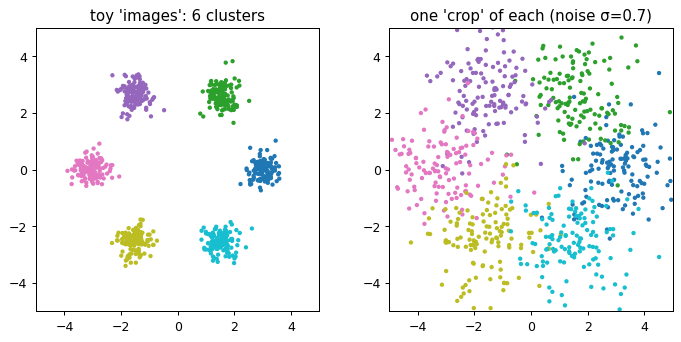

In [7]:
def make_data(n_per_cluster=128, n_clusters=6, radius=3.0, spread=0.3, seed=0):
    g = torch.Generator().manual_seed(seed)
    angles = torch.arange(n_clusters) * (2 * math.pi / n_clusters)
    centers = torch.stack([radius * angles.cos(), radius * angles.sin()], -1)
    X = (centers[:, None, :] + spread * torch.randn(n_clusters, n_per_cluster, 2, generator=g)).reshape(-1, 2)
    y = torch.arange(n_clusters).repeat_interleave(n_per_cluster)
    return X, y

X, y = make_data()
N_CLUSTERS = 6

def augment(x, sigma=0.7):
    return x + sigma * torch.randn_like(x)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
axes[0].scatter(X[:, 0], X[:, 1], c=y, s=6, cmap="tab10"); axes[0].set_title("toy 'images': 6 clusters")
v = augment(X)
axes[1].scatter(v[:, 0], v[:, 1], c=y, s=6, cmap="tab10"); axes[1].set_title("one 'crop' of each (noise σ=0.7)")
for ax in axes: ax.set_aspect("equal"); ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
plt.tight_layout(); plt.show()

In [8]:
def mlp(in_dim=2, out_dim=32, hidden=128):
    return nn.Sequential(
        nn.Linear(in_dim, hidden), nn.GELU(),
        nn.Linear(hidden, hidden), nn.GELU(),
        nn.Linear(hidden, out_dim),
    )

@torch.no_grad()
def code_metrics(q, labels):
    codes = q.argmax(-1)
    counts = codes.bincount(minlength=q.shape[-1])
    top_share = counts.max().item() / len(codes)
    correct = sum(labels[codes == c].bincount().max().item() for c in codes.unique())
    return top_share, correct / len(labels)

@torch.no_grad()
def teacher_dist(teacher, loss_fn, use_center, teacher_temp):
    logits = teacher(X)
    center = loss_fn.center if use_center else 0.0
    return F.softmax((logits - center) / teacher_temp, -1)

def train(use_center, teacher_temp, steps=1500, out_dim=32, m=0.99, lr=1e-3,
          batch=256, log_every=25, seed=0):
    torch.manual_seed(seed)
    student = mlp(out_dim=out_dim)
    teacher = copy.deepcopy(student)
    for p in teacher.parameters():
        p.requires_grad_(False)
    opt = torch.optim.Adam(student.parameters(), lr=lr)
    loss_fn = MiniDINOLoss(out_dim, ncrops=2, teacher_temp=teacher_temp, use_center=use_center)

    hist = {k: [] for k in ["step", "loss", "h_each", "h_mean", "top_share", "code_acc"]}
    for step in range(steps):
        idx = torch.randint(0, len(X), (batch,))
        views = torch.cat([augment(X[idx]), augment(X[idx])])       # global crop 2개
        s_out = student(views)
        with torch.no_grad():
            t_out = teacher(views)
        loss = loss_fn(s_out, t_out)

        opt.zero_grad(); loss.backward(); opt.step()

        with torch.no_grad():                                        # EMA — main_dino.py:346 과 동일
            for ps, pt in zip(student.parameters(), teacher.parameters()):
                pt.mul_(m).add_((1 - m) * ps)

        if step % log_every == 0 or step == steps - 1:
            q = teacher_dist(teacher, loss_fn, use_center, teacher_temp)
            top, acc = code_metrics(q, y)
            hist["step"].append(step)
            hist["loss"].append(loss.item())
            hist["h_each"].append(entropy(q).mean().item())
            hist["h_mean"].append(entropy(q.mean(0)).item())
            hist["top_share"].append(top)
            hist["code_acc"].append(acc)
    return hist, teacher, loss_fn

configs = {
    "none        (center off, temp 0.1)":  dict(use_center=False, teacher_temp=0.1),
    "center only (center on,  temp 0.1)":  dict(use_center=True,  teacher_temp=0.1),
    "sharp only  (center off, temp 0.04)": dict(use_center=False, teacher_temp=0.04),
    "both = DINO (center on,  temp 0.04)": dict(use_center=True,  teacher_temp=0.04),
}

results, models = {}, {}
print(f"{'config':38s} {'loss':>6s} {'h_each':>7s} {'h_mean':>7s} {'top_share':>10s} {'code_acc':>9s}")
for name, cfg in configs.items():
    hist, teacher, loss_fn = train(**cfg)
    results[name], models[name] = hist, (teacher, loss_fn, cfg)
    print(f"{name:38s} {hist['loss'][-1]:6.2f} {hist['h_each'][-1]:7.2f} {hist['h_mean'][-1]:7.2f} "
          f"{hist['top_share'][-1]:10.2f} {hist['code_acc'][-1]:9.2f}")
print(f"\nlog K = log 32 = {math.log(32):.2f},   log(6 clusters) = {math.log(6):.2f},   1/6 = {1/6:.2f}")

config                                   loss  h_each  h_mean  top_share  code_acc
none        (center off, temp 0.1)       2.91    2.90    3.01       0.83      0.33
center only (center on,  temp 0.1)       3.37    3.36    3.46       0.33      0.83
sharp only  (center off, temp 0.04)      0.22    0.00    1.24       0.50      0.67
both = DINO (center on,  temp 0.04)      0.82    0.59    2.38       0.17      1.00

log K = log 32 = 3.47,   log(6 clusters) = 1.79,   1/6 = 0.17


`temp 0.1`인 두 설정은 teacher와 student의 온도가 같다 — 즉 **sharpening이 없는** 상태다.

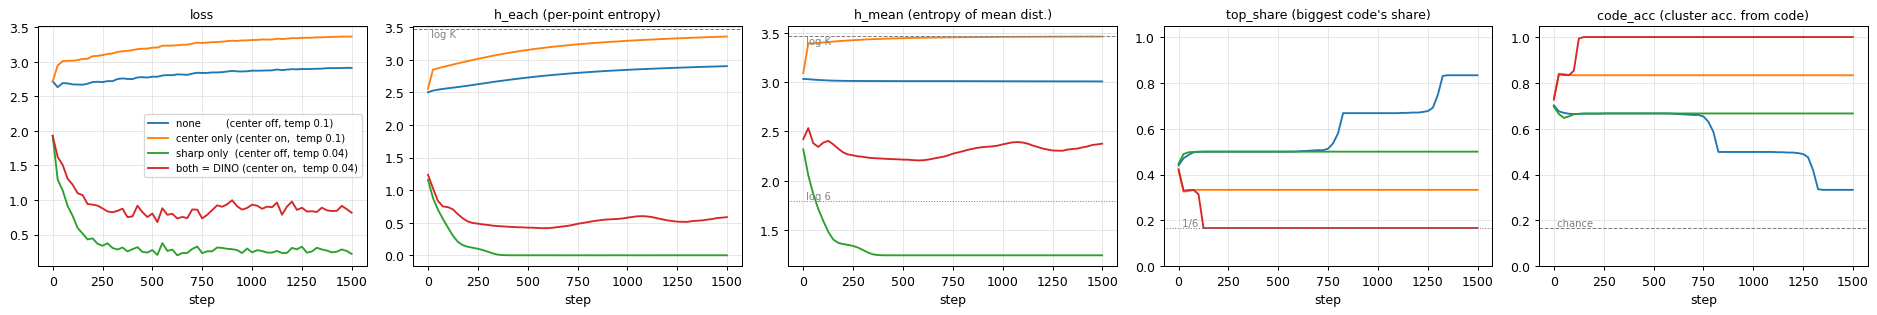

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(21, 3.6))
panels = [("loss", "loss"), ("h_each", "h_each (per-point entropy)"), ("h_mean", "h_mean (entropy of mean dist.)"),
          ("top_share", "top_share (biggest code's share)"), ("code_acc", "code_acc (cluster acc. from code)")]
for ax, (key, title) in zip(axes, panels):
    for name, r in results.items():
        ax.plot(r["step"], r[key], label=name)
    ax.set_title(title, fontsize=10); ax.set_xlabel("step"); ax.grid(alpha=.3)
for ax in axes[1:3]:
    ax.axhline(math.log(32), ls="--", c="gray", lw=.8); ax.text(0, math.log(32), " log K", va="top", c="gray", fontsize=8)
axes[2].axhline(math.log(6), ls=":", c="gray", lw=.8); axes[2].text(0, math.log(6), " log 6", va="bottom", c="gray", fontsize=8)
axes[3].axhline(1 / 6, ls=":", c="gray", lw=.8); axes[3].text(0, 1 / 6, " 1/6", va="bottom", c="gray", fontsize=8)
axes[4].axhline(1 / 6, ls="--", c="gray", lw=.8); axes[4].text(0, 1 / 6, " chance", va="bottom", c="gray", fontsize=8)
axes[3].set_ylim(0, 1.05); axes[4].set_ylim(0, 1.05)
axes[0].legend(fontsize=8, loc="center right")
plt.tight_layout(); plt.show()

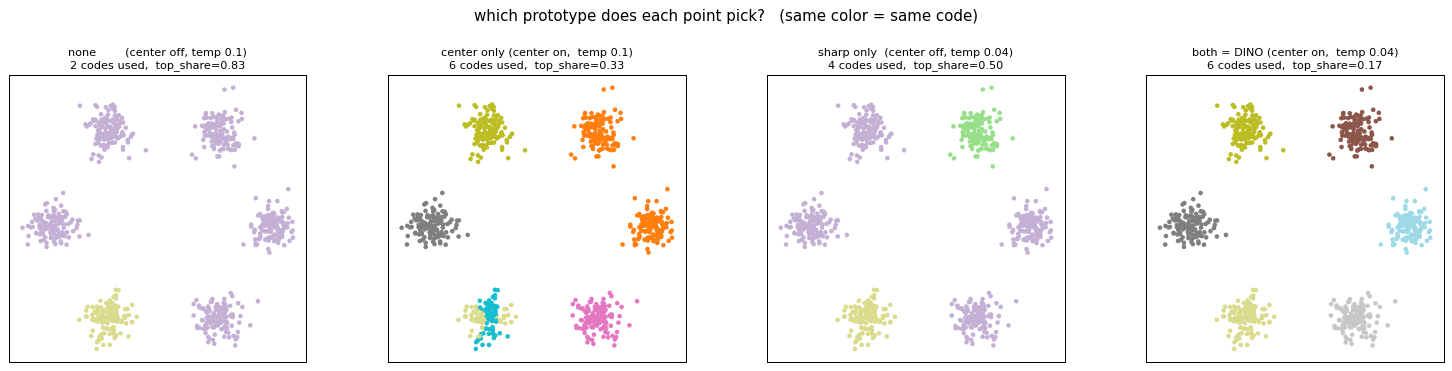

In [10]:
# 각 점이 최종적으로 어느 코드(prototype)를 골랐는지 — 색 = 코드
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, (name, (teacher, loss_fn, cfg)) in zip(axes, models.items()):
    q = teacher_dist(teacher, loss_fn, **cfg)
    codes = q.argmax(-1)
    n_codes = codes.unique().numel()
    ax.scatter(X[:, 0], X[:, 1], c=codes, s=7, cmap="tab20", vmin=0, vmax=31)
    ax.set_title(f"{name}\n{n_codes} codes used,  top_share={results[name]['top_share'][-1]:.2f}", fontsize=9)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("which prototype does each point pick?   (same color = same code)", y=1.02)
plt.tight_layout(); plt.show()

### 읽는 법

토이가 작아서 붕괴가 "완전히" 일어나지는 않지만, 네 설정이 **어느 방향으로 끌려가는지**는 분명하다.

- **none** (둘 다 없음): `h_each ≈ h_mean ≈ 2.9`로 높고(균등 쪽), 동시에 `top_share ≈ 0.8` — 거의 모든 점이 **같은 차원**을 argmax로 고른다.
  "퍼져 있는데 다들 같은 데를 살짝 더 가리키는" 상태. 코드로 클러스터를 맞히는 정확도가 chance 근처다. 산점도에서 한 색이 판을 덮는다.
- **center only** (sharpening 없음): `h_each → log K`. centering이 한 차원 지배는 막았지만(`top_share` 0.33), teacher가 student와 같은 온도라
  뾰족해질 이유가 없다 → 분포가 **균등** 쪽으로 퍼진다. loss도 `log K` 근처에서 멈춘다.
- **sharp only** (centering 없음): `h_each = 0` — 모든 점이 확신에 찬 원-핫이다. 그런데 `h_mean ≈ 1.2`(≈ log 3.5), `top_share = 0.5`:
  6개 클러스터가 **~4개 코드로 합쳐지고, 한 코드가 데이터 절반을 먹는다**. 한 차원이 지배하기 시작하는 원-핫 붕괴의 초기 모습이다.
  산점도에서 인접 클러스터들이 같은 색으로 묶인다.
- **both = DINO**: `h_each` 낮음(≈0.6, 확신) + `h_mean` 높음(≈2.4, 차원을 골고루 씀) + `top_share = 1/6` + `code_acc = 1.0`.
  **정확히 6개 코드가 6개 클러스터에 1:1**로 붙었다.
  레이블을 한 번도 안 봤는데 클러스터링이 끝났다.

**loss 열을 다시 보라.** `sharp only`의 loss(≈0.2)가 `both`(≈0.8)보다 **낮다**. 표현은 `both`가 압도적으로 좋은데 loss는 반대로 말한다 —
4절에서 상수 출력으로 보여준 "loss는 붕괴를 못 잡는다"가 실제 학습에서도 그대로 나타난다.

원본 논문 Fig. 7이 ImageNet에서 보여주는 것(centering만 → 엔트로피 ↑ log K, sharpening만 → 엔트로피 ↓ 0)과 같은 그림이다.

## 6. 요약

### 두 장치는 서로 반대 방향으로 민다

```python
teacher_out = F.softmax((teacher_output - self.center) / temp, dim=-1)
#                        └── centering ─────┘   └ sharpening
```

| 장치 | 하는 일 | 막는 붕괴 | 혼자 두면 |
|---|---|---|---|
| **centering** | 배치 평균(EMA)을 로짓에서 뺀다. 늘 큰 차원은 center도 커져 상쇄 | 원-핫 붕괴 (한 차원 지배) | **균등 붕괴**로 간다 |
| **sharpening** | teacher 온도 0.04 < student 온도 0.1 | 균등 붕괴 | **원-핫 붕괴**로 간다 |

둘을 같이 걸어야 "적당히 뾰족하면서 입력마다 다른" 분포에 머문다.
`--teacher_temp`가 0.04에서 warmup으로 천천히 올라가는 것도, 초기에 sharpening이 너무 세면 원-핫 쪽으로 밀려 불안정해지기 때문이다.

### 원본 코드 대응

| 이 노트북 | 원본 |
|---|---|
| `MiniDINOLoss.forward` | [main_dino.py:380](../main_dino.py#L380) `DINOLoss.forward` |
| `update_center` (mean) | [main_dino.py:405](../main_dino.py#L405) — `sum` → `dist.all_reduce` → `/ (B × world_size)` |
| `teacher_temp` 상수 | `teacher_temp_schedule[epoch]` — warmup 선형 증가 |
| EMA 루프 | [main_dino.py:346](../main_dino.py#L346) `param_k.mul_(m).add_((1-m)*param_q)` |
| `code_acc` / `top_share` | `eval_knn.py`의 역할 (토이용 대체 지표, 5절 참고) |

### 실전 함정

1. **loss는 붕괴를 못 잡는다.** 4절에서 봤듯 붕괴한 모델의 loss는 건강한 모델과 같거나 더 낮다.
   `eval_knn.py`를 주기적으로 돌리거나, teacher 출력의 `h_each`/`h_mean`/`top_share`를 로깅해야 조기 감지가 된다.
2. **`update_center`는 `dist.all_reduce`를 쓴다.** 프로세스 그룹이 초기화되지 않으면 centering이 깨진다.
   단일 GPU 폴백 경로에서도 그룹이 잡히는지 확인.
3. **`center_momentum=0.9`** 는 배치 통계의 EMA다. 배치가 아주 작으면 center가 노이즈에 흔들려 centering 효과가 약해진다.